# Práctica: Comparación de modelos de regresión

**Materia:** Tópicos de Big Data
**Tema:** Introducción al aprendizaje supervisado mediante modelos de regresión
**Herramientas:** Python · Jupyter Notebook · Pandas · NumPy · Matplotlib · Scikit-learn

---

## 1. Objetivo

Construir diferentes modelos de aprendizaje supervisado para realizar **proyecciones del número de nacimientos y defunciones** de un país, utilizando datos históricos.

Durante la práctica se implementarán y compararán visualmente tres modelos:

1. Regresión lineal
2. Regresión polinomial
3. Random Forest Regressor

Al finalizar, podrás observar cómo **diferentes modelos generan predicciones diferentes utilizando exactamente los mismos datos**.

> **Nota:** En esta práctica **no** se realizará todavía la evaluación formal de los modelos. La evaluación mediante métricas se realizará en la siguiente sesión.

---

## 2. Dataset

Utilizaremos información de **Our World in Data (OWID)** sobre nacimientos y defunciones, que incluye datos históricos y proyecciones hasta el año 2100.

Fuente: *Our World in Data – Births and deaths projected to 2100* (basado en las estimaciones y proyecciones de la ONU).

El dataset contiene información por **país (o región) y año**.

# PARTE 1. Importar las bibliotecas

En esta práctica utilizaremos:

* **Pandas** para trabajar con el dataset.
* **NumPy** para trabajar con arreglos y preparar datos.
* **Matplotlib** para visualizar los datos y las predicciones.
* **Scikit-learn** para construir los modelos de Machine Learning.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

# PARTE 2. Cargar el dataset

## 3. Cargar los datos

Leemos el archivo CSV directamente desde la página de OWID.

> **Si no hay internet (o la descarga falla):** descarga el CSV desde la URL de la celda siguiente, guárdalo en la misma carpeta que este notebook con el nombre `births-and-deaths-projected-to-2100.csv` y vuelve a ejecutar la celda. El código lo detecta automáticamente.

In [59]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


## 4. Explorar el dataset

Observemos la estructura del `DataFrame`.

In [60]:
print("Dimensiones (filas, columnas):", df.shape)
print()
print("Columnas:")
for columna in df.columns:
    print("  -", columna)

Dimensiones (filas, columnas): (39562, 7)

Columnas:
  - entity
  - code
  - year
  - deaths__sex_all__age_all__variant_estimates
  - deaths__sex_all__age_all__variant_medium__projected
  - births__sex_all__age_all__variant_estimates
  - births__sex_all__age_all__variant_medium__projected


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39562 entries, 0 to 39561
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   entity                                               39562 non-null  str    
 1   code                                                 38354 non-null  str    
 2   year                                                 39562 non-null  int64  
 3   deaths__sex_all__age_all__variant_estimates          18944 non-null  float64
 4   deaths__sex_all__age_all__variant_medium__projected  19712 non-null  float64
 5   births__sex_all__age_all__variant_estimates          19166 non-null  float64
 6   births__sex_all__age_all__variant_medium__projected  19943 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 2.1 MB


In [62]:
df.head(10)

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN
5,Afghanistan,AFG,1955,286725.0,NaN,417650.0,NaN
6,Afghanistan,AFG,1956,286654.0,NaN,425071.0,NaN
7,Afghanistan,AFG,1957,286114.0,NaN,432044.0,NaN
8,Afghanistan,AFG,1958,285911.0,NaN,439867.0,NaN
9,Afghanistan,AFG,1959,285500.0,NaN,447510.0,NaN


Revisemos las entidades disponibles:

In [63]:
print("Número de entidades:", df["entity"].nunique())
df["entity"].unique()

Número de entidades: 262


<StringArray>
[      'Afghanistan',            'Africa',       'Africa (UN)',
           'Albania',           'Algeria',    'American Samoa',
     'Americas (UN)',           'Andorra',            'Angola',
          'Anguilla',
 ...
           'Vanuatu',           'Vatican',         'Venezuela',
           'Vietnam', 'Wallis and Futuna',    'Western Sahara',
             'World',             'Yemen',            'Zambia',
          'Zimbabwe']
Length: 262, dtype: str

### Pregunta

**¿Cuál es la unidad de observación de cada fila del dataset?**

*La unidad de observación es una entidad (país o región) en un año específico.*



### ANÁLISIS DEMOGRÁFICO - CHINA

In [117]:
df = df.rename(columns={
    "entity": "Entity",
    "year": "Year",
    "births_sex_all_age_all_variant_estimates": "births_estimates",
    "births_sex_all_age_all_variant_medium_projected": "births_projected",
    "deaths_sex_all_age_all_variant_estimates": "deaths_estimates",
    "deaths_sex_all_age_all_variant_medium_projected": "deaths_projected"
})

# Unificar columnas
df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])

# Filtrar para China
df_china = df[df["Entity"] == "China"]

# Separar histórico y proyectado
df_historico = df_china[df_china["Year"] <= 2023]
df_proyectado = df_china[df_china["Year"] > 2023]

In [118]:
X = df_historico[["Year"]]
y_nacimientos = df_historico["births"]

anios_futuros = np.arange(2024, 2101).reshape(-1, 1)
X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

#Regresión Lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y_nacimientos)
pred_lineal_futuras = modelo_lineal.predict(X_futuro)

#Regresión Polinomial
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
modelo_polinomial = LinearRegression()
modelo_polinomial.fit(X_poly, y_nacimientos)
anios_futuros_poly = poly.transform(X_futuro)
pred_poly_futuras = modelo_polinomial.predict(anios_futuros_poly)

#Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X, y_nacimientos)
pred_rf_futuras = modelo_rf.predict(X_futuro)

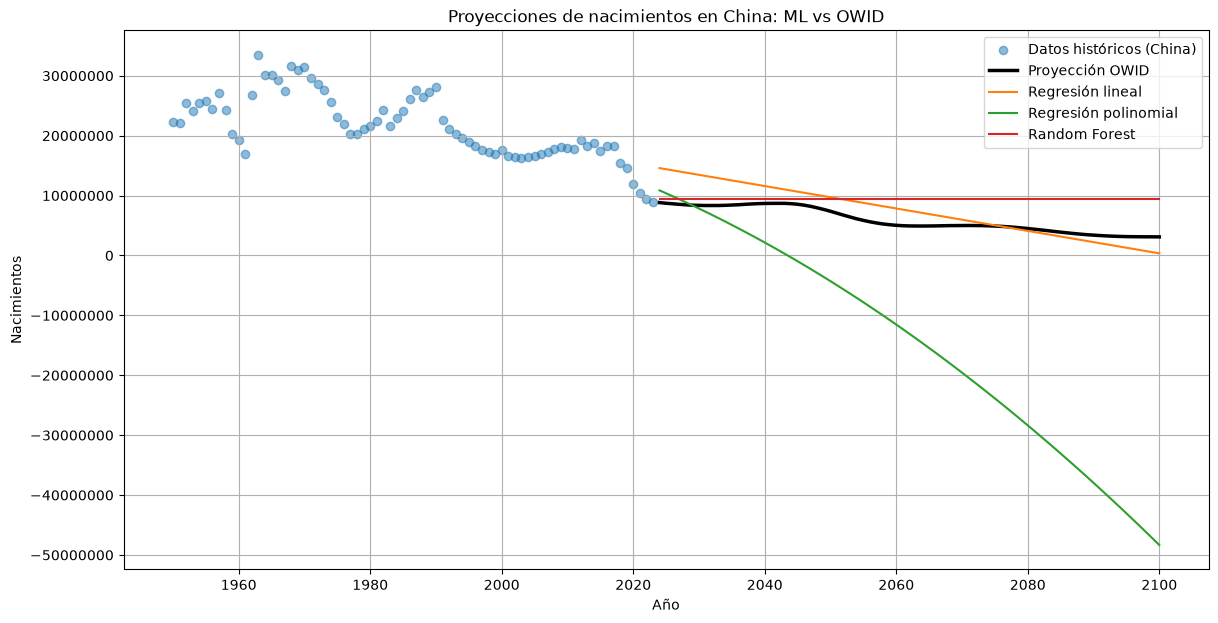

In [119]:
plt.figure(figsize=(14, 7))

# Históricos y OWID
plt.scatter(df_historico["Year"], df_historico["births"], label="Datos históricos (China)", alpha=0.5)
plt.plot(df_proyectado["Year"], df_proyectado["births"], color="black", linewidth=2.5, label="Proyección OWID")

# Modelos
plt.plot(anios_futuros.flatten(), pred_lineal_futuras, color="tab:orange", label="Regresión lineal")
plt.plot(anios_futuros.flatten(), pred_poly_futuras, color="tab:green", label="Regresión polinomial")
plt.plot(anios_futuros.flatten(), pred_rf_futuras, color="tab:red", label="Random Forest")

plt.title("Proyecciones de nacimientos en China: ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

### observaciónes

*Datos históricos (Puntos azules): Muestran fluctuaciones extremas (caídas y picos abruptos entre 1960 y 1990) que dificultan el aprendizaje de una tendencia uniforme.*

*Regresión Lineal (Naranja): Promedia toda la historia y traza un descenso recto que ignora las fluctuaciones recientes y sobreestima los nacimientos a corto plazo.*

*Regresión Polinomial (Verde): Falla drásticamente al proyectar una caída acelerada hacia -50 millones de nacimientos para 2100, un valor biológicamente imposible.*

*Random Forest (Rojo): Al no poder extrapolar tendencias fuera de los datos que conoce, se congela en una línea plana horizontal a partir de 2023.*

*Proyección OWID (Negro): Muestra un declive realista y suavizado, evidenciando que los algoritmos puramente matemáticos no pueden reemplazar modelos demográficos complejos.*